TITLE & BUSINESS INTRODUCTION

# ITSM Priority Prediction and Classification System

## Project Objective

This notebook focuses on building Machine Learning classification models for IT Service Management (ITSM) operations.

The primary business goals are:

1. Predicting high-priority incidents
2. Supporting automatic ticket tagging
3. Reducing incorrect ticket routing
4. Identifying operational risk indicators for RFC analysis

The models developed in this notebook help improve:
- incident response efficiency
- operational automation
- service reliability
- workload management

This notebook uses classification algorithms including:
- Logistic Regression
- Random Forest
- XGBoost


In [28]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


IMPORT LIBRARIES

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

LOAD CLEAN DATASET

## Loading Processed Dataset

The cleaned and preprocessed ITSM dataset is loaded for machine learning workflows.

The dataset already contains:
- cleaned records
- engineered features
- reduced missing values
- operational incident information

This dataset is now suitable for classification models.

In [30]:
df = pd.read_csv(
    "../data/processed/itsm_cleaned.csv",
    low_memory=False
)

print("successfully loaded dataset")

successfully loaded dataset


In [31]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,Open_Year,Open_Month,Open_Day,Open_Hour,Open_Weekday
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,2013-11-04 13:51:00,3.871691e+09,Other,1.0,SD0000007,2012,2,5,13,6
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,2013-12-02 12:36:00,4.354786e+09,Software,1.0,SD0000011,2012,3,12,15,0
2,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,2013-11-14 09:31:00,4.321833e+09,Operator error,1.0,SD0000025,2012,7,17,11,1
3,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,2013-11-08 13:55:00,3.383903e+09,Other,1.0,SD0000029,2012,8,10,11,4
4,WBA000124,application,Web Based Application,WBS000088,IM0000013,Closed,4,4,4.0,0.006676,...,2013-11-08 13:54:00,3.383437e+09,Other,1.0,SD0000031,2012,8,10,11,4


DATASET INSPECTION

## Dataset Inspection

Initial inspection helps validate:
- feature availability
- dataset quality
- data types
- machine learning readiness

In [32]:
df.shape

(45226, 26)

DROP LEAKAGE COLUMNS



In [33]:
leakage_cols = [
    'Impact',
    'Urgency',
    'Incident_ID',
    'KB_number',
    'Related_Interaction',
    'WBS'
]

df.drop(
    columns=leakage_cols,
    inplace=True,
    errors='ignore'
)

REMOVE DATETIME COLUMNS

In [34]:
datetime_cols = [
    'Open_Time',
    'Resolved_Time',
    'Close_Time'
]

df.drop(
    columns=datetime_cols,
    inplace=True,
    errors='ignore'
)

HANDLE REMAINING NULLS

In [35]:
df.isnull().sum()

CI_Name                       0
CI_Cat                        0
CI_Subcat                     0
Status                        0
Priority                      0
number_cnt                    0
Category                      0
Alert_Status                  0
No_of_Reassignments           0
Handle_Time_hrs               0
Closure_Code                  0
No_of_Related_Interactions    0
Open_Year                     0
Open_Month                    0
Open_Day                      0
Open_Hour                     0
Open_Weekday                  0
dtype: int64

In [36]:
df.fillna("unknown",inplace=True)

ENCODE CATEGORICAL FEATURES



In [37]:
label_encoders = {}

categorical_cols = df.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    label_encoders[col] = le

TARGET & FEATURES

In [38]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

df['Priority'] = target_encoder.fit_transform(
    df['Priority']
)

In [39]:
X = df.drop('Priority', axis=1)
y = df['Priority']

TRAIN TEST SPLIT

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

SCALING

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.transform(X_test)

MODEL TRAINING

LOGISTIC REGRESSION

In [43]:
# Logistic Regression
lr_model = LogisticRegression(
    max_iter=5000
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

RANDOM FOREST

In [46]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

XGBOOST

In [47]:
#XGBoost
xgb_model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

EVALUATION FUNCTION

In [49]:
def evaluate_model(model_name, y_test, y_pred):

    print(f"\n{'='*50}")
    print(model_name)
    print(f"{'='*50}")

    print("\nAccuracy Score:\n")

    print(
        accuracy_score(y_test, y_pred)
    )

    print("\nClassification Report:\n")

    print(
        classification_report(y_test, y_pred)
    )

    print("\nConfusion Matrix:\n")

    print(
        confusion_matrix(y_test, y_pred)
    )

In [50]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)


Logistic Regression

Accuracy Score:

0.6625027636524431

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.01      0.01       139
           2       0.00      0.00      0.00      1065
           3       0.61      0.97      0.75      4544
           4       0.90      0.48      0.63      3297

    accuracy                           0.66      9046
   macro avg       0.40      0.29      0.28      9046
weighted avg       0.64      0.66      0.60      9046


Confusion Matrix:

[[   0    0    0    1    0]
 [   0    1    2  131    5]
 [   0    1    0 1026   38]
 [   0    0    1 4402  141]
 [   0    0    0 1707 1590]]

Random Forest

Accuracy Score:

0.8171567543665709

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.58      0.51      0.54       139
           2       0.83    

C:\Program Files\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Program Files\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Program Files\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Program Files\Pytho

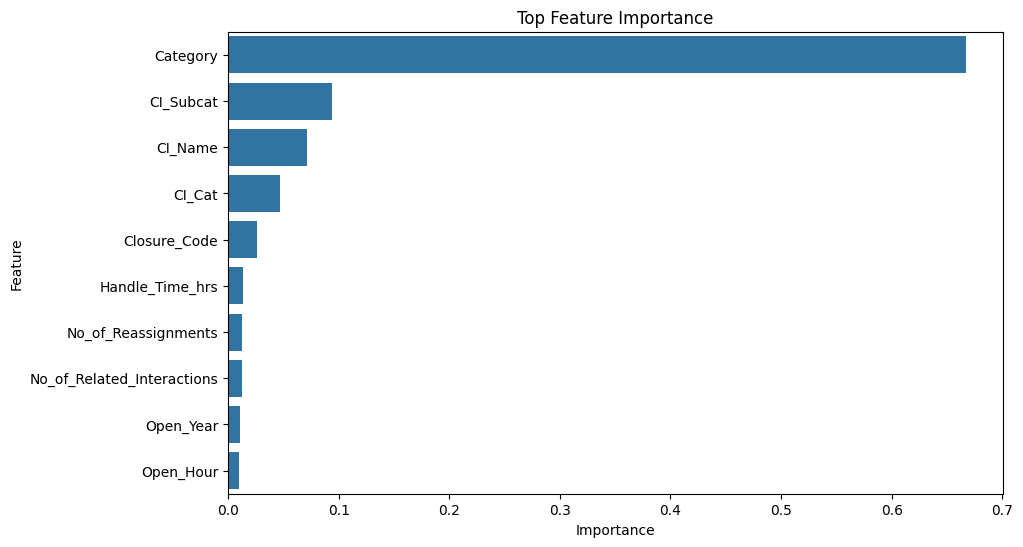

In [51]:
#ADD FEATURE IMPORTANCE GRAPH
feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top Feature Importance")

plt.show()


In [52]:
#SAVE BEST MODEL

import joblib

joblib.dump(
    xgb_model,
    "../models/priority_model.pkl"
)

print("Model saved successfully")

Model saved successfully
